# Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

#Loading Dataset

In [37]:
df = pd.read_csv("/content/heart_disease_uci.csv")

# ============================================================
# STEP 2: DATA CLEANING & PREPROCESSING
# ============================================================

Check missing values

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [39]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [40]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [25]:
print("\n" + "=" * 80)
print("STEP 2: DATA CLEANING & PREPROCESSING")
print("=" * 80)


STEP 2: DATA CLEANING & PREPROCESSING


 Check missing values




In [42]:
print("\n Missing Values Check:")
missing = df.isnull().sum()
print(missing)
print(f"\n Missing Value Percentages:")
for col in df.columns:
    pct = (df[col].isnull().sum() / len(df)) * 100
    if pct > 0:
        print(f"   • {col}: {pct:.1f}%")


 Missing Values Check:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

 Missing Value Percentages:
   • trestbps: 6.4%
   • chol: 3.3%
   • fbs: 9.8%
   • restecg: 0.2%
   • thalch: 6.0%
   • exang: 6.0%
   • oldpeak: 6.7%
   • slope: 33.6%
   • ca: 66.4%
   • thal: 52.8%


Drop 'id' column as it's not useful for prediction

In [43]:
df = df.drop('id', axis=1)
print("\n Dropped 'id' column")


Dropped 'id' column


In [29]:
print("\n Handling Missing Values:")


 Handling Missing Values:


For numerical columns: fill with median

In [44]:
numerical_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in numerical_cols:
    if col in df.columns:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"   • {col}: Filled {missing[col]} missing with median ({median_val})")

   • trestbps: Filled 59 missing with median (130.0)
   • chol: Filled 30 missing with median (223.0)
   • thalch: Filled 55 missing with median (140.0)
   • oldpeak: Filled 62 missing with median (0.5)
   • ca: Filled 611 missing with median (0.0)


/tmp/ipykernel_15150/1771000067.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


For categorical columns: fill with mode

In [45]:
categorical_cols = ['fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"   • {col}: Filled {missing[col]} missing with mode ({mode_val})")

   • fbs: Filled 90 missing with mode (False)
   • restecg: Filled 2 missing with mode (normal)
   • exang: Filled 55 missing with mode (False)
   • slope: Filled 309 missing with mode (flat)
   • thal: Filled 486 missing with mode (normal)


/tmp/ipykernel_15150/3708697159.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_15150/3708697159.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(mode_val, inplace=True)


Verify no missing values remain

In [46]:
print(f"\n Remaining Missing Values: {df.isnull().sum().sum()}")


 Remaining Missing Values: 0


Check for duplicates

In [47]:
print(f"\n Duplicate Rows: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f" Removed duplicates. New shape: {df.shape}")



Duplicate Rows: 2
Removed duplicates. New shape: (918, 15)


# ============================================================
# STEP 3: FEATURE ENGINEERING - TARGET VARIABLE
# ============================================================

Convert 'num' to binary target (0 = No Disease, 1-4 = Disease)

In [48]:
print("\n🔧 Converting target variable 'num' to binary:")
print(f"   • Original 'num' distribution:")
print(df['num'].value_counts().sort_index())


🔧 Converting target variable 'num' to binary:
   • Original 'num' distribution:
num
0    410
1    265
2    108
3    107
4     28
Name: count, dtype: int64



Create binary target: 0 = No Disease, 1 = Disease


In [49]:
df['target'] = (df['num'] > 0).astype(int)
df = df.drop('num', axis=1)

In [50]:
print(f"\n Binary Target Distribution:")
target_dist = df['target'].value_counts()
print(target_dist)
print(f"   • No Heart Disease (0): {target_dist[0]} ({target_dist[0]/len(df)*100:.1f}%)")
print(f"   • Heart Disease (1): {target_dist[1]} ({target_dist[1]/len(df)*100:.1f}%)")


 Binary Target Distribution:
target
1    508
0    410
Name: count, dtype: int64
   • No Heart Disease (0): 410 (44.7%)
   • Heart Disease (1): 508 (55.3%)


# ============================================================
# STEP 4: ENCODE CATEGORICAL VARIABLES
# ============================================================

In [55]:
from sklearn.preprocessing import LabelEncoder
print("\n" + "=" * 80)
print("STEP 4: ENCODE CATEGORICAL VARIABLES")
print("=" * 80)

# Identify categorical columns
categorical_columns = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
print("\n🔧 Encoding Categorical Variables:")

# Label encode categorical variables
label_encoders = {}
for col in categorical_columns:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f"   • {col}: {len(le.classes_)} categories encoded")

print(f"\n Final Data Types:")
print(df.dtypes)


STEP 4: ENCODE CATEGORICAL VARIABLES

 Encoding Categorical Variables:
   • sex: 2 categories encoded
   • dataset: 4 categories encoded
   • cp: 4 categories encoded
   • fbs: 2 categories encoded
   • restecg: 3 categories encoded
   • exang: 2 categories encoded
   • slope: 3 categories encoded
   • thal: 3 categories encoded

 Final Data Types:
age           int64
sex           int64
dataset       int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal          int64
target        int64
dtype: object



# ============================================================
# STEP 5: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================


STEP 5: EXPLORATORY DATA ANALYSIS (EDA)


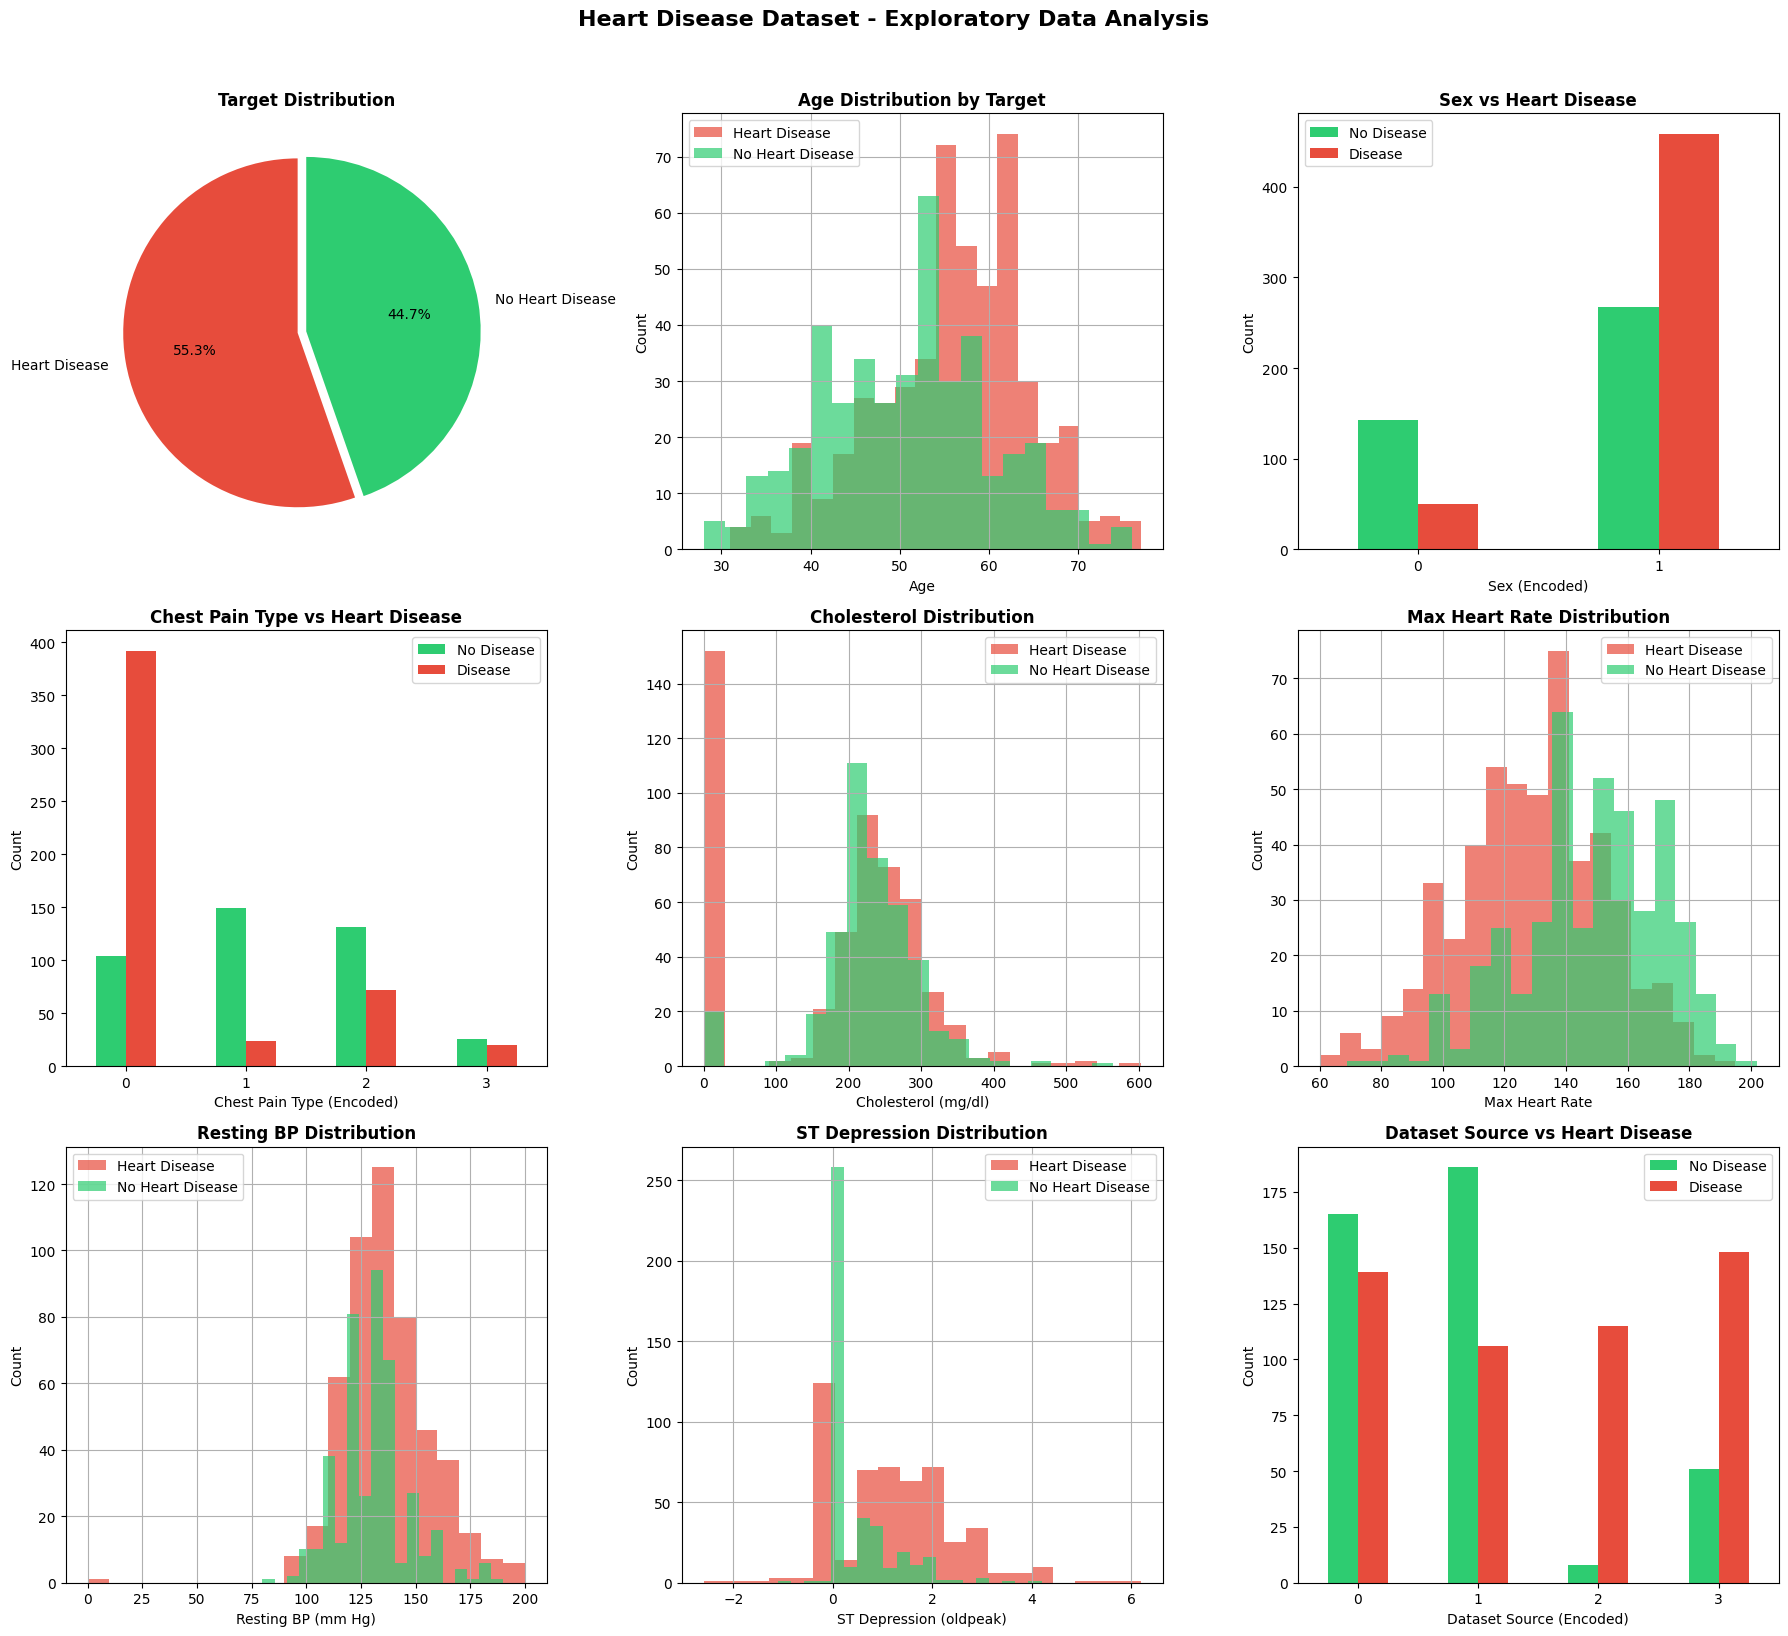


 EDA Visualizations saved!


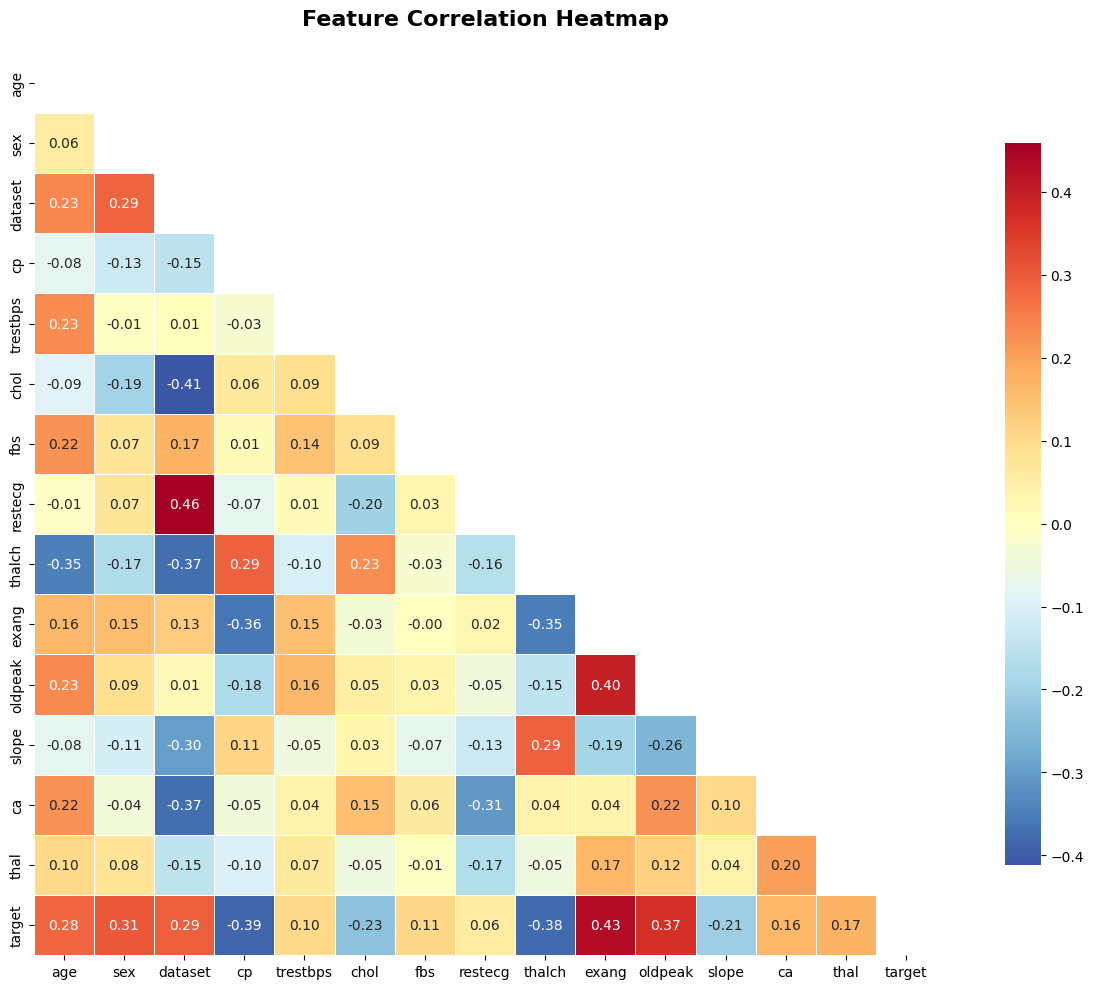


 Key Correlations with Target:
   • exang: 0.432
   • cp: -0.387
   • thalch: -0.381
   • oldpeak: 0.367
   • sex: 0.305
   • dataset: 0.295
   • age: 0.282
   • chol: -0.229
   • slope: -0.206
   • thal: 0.173
   • ca: 0.165
   • fbs: 0.108
   • trestbps: 0.099
   • restecg: 0.057


In [56]:
print("\n" + "=" * 80)
print("STEP 5: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)

# Create comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle('Heart Disease Dataset - Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.02)

# 1. Target Distribution
ax1 = axes[0, 0]
colors = ['#e74c3c', '#2ecc71']
target_counts = df['target'].value_counts()
ax1.pie(target_counts, labels=['Heart Disease', 'No Heart Disease'], autopct='%1.1f%%',
        colors=colors, startangle=90, explode=(0.05, 0))
ax1.set_title('Target Distribution', fontweight='bold')

# 2. Age Distribution by Target
ax2 = axes[0, 1]
df[df['target']==1]['age'].hist(bins=20, alpha=0.7, label='Heart Disease', color='#e74c3c', ax=ax2)
df[df['target']==0]['age'].hist(bins=20, alpha=0.7, label='No Heart Disease', color='#2ecc71', ax=ax2)
ax2.set_xlabel('Age')
ax2.set_ylabel('Count')
ax2.set_title('Age Distribution by Target', fontweight='bold')
ax2.legend()

# 3. Sex vs Target
ax3 = axes[0, 2]
sex_target = pd.crosstab(df['sex'], df['target'])
sex_target.plot(kind='bar', ax=ax3, color=['#2ecc71', '#e74c3c'])
ax3.set_xlabel('Sex (Encoded)')
ax3.set_ylabel('Count')
ax3.set_title('Sex vs Heart Disease', fontweight='bold')
ax3.legend(['No Disease', 'Disease'])
ax3.tick_params(axis='x', rotation=0)

# 4. Chest Pain Type vs Target
ax4 = axes[1, 0]
cp_target = pd.crosstab(df['cp'], df['target'])
cp_target.plot(kind='bar', ax=ax4, color=['#2ecc71', '#e74c3c'])
ax4.set_xlabel('Chest Pain Type (Encoded)')
ax4.set_ylabel('Count')
ax4.set_title('Chest Pain Type vs Heart Disease', fontweight='bold')
ax4.legend(['No Disease', 'Disease'])
ax4.tick_params(axis='x', rotation=0)

# 5. Cholesterol Distribution
ax5 = axes[1, 1]
df[df['target']==1]['chol'].hist(bins=20, alpha=0.7, label='Heart Disease', color='#e74c3c', ax=ax5)
df[df['target']==0]['chol'].hist(bins=20, alpha=0.7, label='No Heart Disease', color='#2ecc71', ax=ax5)
ax5.set_xlabel('Cholesterol (mg/dl)')
ax5.set_ylabel('Count')
ax5.set_title('Cholesterol Distribution', fontweight='bold')
ax5.legend()

# 6. Max Heart Rate vs Target
ax6 = axes[1, 2]
df[df['target']==1]['thalch'].hist(bins=20, alpha=0.7, label='Heart Disease', color='#e74c3c', ax=ax6)
df[df['target']==0]['thalch'].hist(bins=20, alpha=0.7, label='No Heart Disease', color='#2ecc71', ax=ax6)
ax6.set_xlabel('Max Heart Rate')
ax6.set_ylabel('Count')
ax6.set_title('Max Heart Rate Distribution', fontweight='bold')
ax6.legend()

# 7. Resting BP vs Target
ax7 = axes[2, 0]
df[df['target']==1]['trestbps'].hist(bins=20, alpha=0.7, label='Heart Disease', color='#e74c3c', ax=ax7)
df[df['target']==0]['trestbps'].hist(bins=20, alpha=0.7, label='No Heart Disease', color='#2ecc71', ax=ax7)
ax7.set_xlabel('Resting BP (mm Hg)')
ax7.set_ylabel('Count')
ax7.set_title('Resting BP Distribution', fontweight='bold')
ax7.legend()

# 8. ST Depression (oldpeak) vs Target
ax8 = axes[2, 1]
df[df['target']==1]['oldpeak'].hist(bins=20, alpha=0.7, label='Heart Disease', color='#e74c3c', ax=ax8)
df[df['target']==0]['oldpeak'].hist(bins=20, alpha=0.7, label='No Heart Disease', color='#2ecc71', ax=ax8)
ax8.set_xlabel('ST Depression (oldpeak)')
ax8.set_ylabel('Count')
ax8.set_title('ST Depression Distribution', fontweight='bold')
ax8.legend()

# 9. Dataset Source vs Target
ax9 = axes[2, 2]
dataset_target = pd.crosstab(df['dataset'], df['target'])
dataset_target.plot(kind='bar', ax=ax9, color=['#2ecc71', '#e74c3c'])
ax9.set_xlabel('Dataset Source (Encoded)')
ax9.set_ylabel('Count')
ax9.set_title('Dataset Source vs Heart Disease', fontweight='bold')
ax9.legend(['No Disease', 'Disease'])
ax9.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n EDA Visualizations saved!")


# Correlation Heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Key Correlations with Target:")
target_corr = correlation_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
for feat, corr in target_corr.items():
    print(f"   • {feat}: {corr:.3f}")


# ============================================================
# STEP 6: FEATURE ENGINEERING & DATA PREPARATION
# ============================================================

In [57]:
print("\n" + "=" * 80)
print("STEP 6: FEATURE ENGINEERING & DATA PREPARATION")
print("=" * 80)

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"\n Features (X): {X.shape}")
print(f" Target (y): {y.shape}")

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n Train Set: {X_train.shape[0]} samples")
print(f" Test Set: {X_test.shape[0]} samples")

# Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Data split and scaled successfully!")
print("   • StandardScaler applied for Logistic Regression")
print("   • Stratified split maintains class balance")


STEP 6: FEATURE ENGINEERING & DATA PREPARATION

 Features (X): (918, 14)
 Target (y): (918,)

 Train Set: 734 samples
 Test Set: 184 samples

 Data split and scaled successfully!
   • StandardScaler applied for Logistic Regression
   • Stratified split maintains class balance


# ============================================================
# STEP 7: MODEL TRAINING & HYPERPARAMETER TUNING
# ============================================================

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
print("\n" + "=" * 80)
print("STEP 7: MODEL TRAINING & HYPERPARAMETER TUNING")
print("=" * 80)

# 1. Logistic Regression with Grid Search
print("\n🔧 Training Logistic Regression...")
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
lr_grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), lr_params,
                       cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
print(f"    Best LR Params: {lr_grid.best_params_}")
print(f"    Best CV ROC-AUC: {lr_grid.best_score_:.4f}")

# 2. Decision Tree with Grid Search
print("\n🔧 Training Decision Tree...")
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params,
                       cv=5, scoring='roc_auc', n_jobs=-1)
dt_grid.fit(X_train, y_train)
print(f"    Best DT Params: {dt_grid.best_params_}")
print(f"    Best CV ROC-AUC: {dt_grid.best_score_:.4f}")

# 3. Random Forest (Bonus Model)
print("\n🔧 Training Random Forest...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params,
                       cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f"    Best RF Params: {rf_grid.best_params_}")
print(f"    Best CV ROC-AUC: {rf_grid.best_score_:.4f}")

# Best models
best_lr = lr_grid.best_estimator_
best_dt = dt_grid.best_estimator_
best_rf = rf_grid.best_estimator_

print("\n All models trained and tuned successfully!")



STEP 7: MODEL TRAINING & HYPERPARAMETER TUNING

 Training Logistic Regression...
    Best LR Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
    Best CV ROC-AUC: 0.8749

 Training Decision Tree...
    Best DT Params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
    Best CV ROC-AUC: 0.8318

🔧 Training Random Forest...
    Best RF Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
    Best CV ROC-AUC: 0.8863

 All models trained and tuned successfully!


# ============================================================
# STEP 8: MODEL EVALUATION
# ============================================================


In [62]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("\n" + "=" * 80)
print("STEP 8: MODEL EVALUATION")
print("=" * 80)

# Predictions
lr_pred = best_lr.predict(X_test_scaled)
lr_pred_proba = best_lr.predict_proba(X_test_scaled)[:, 1]

dt_pred = best_dt.predict(X_test)
dt_pred_proba = best_dt.predict_proba(X_test)[:, 1]

rf_pred = best_rf.predict(X_test)
rf_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Evaluation function
def evaluate_model(name, y_true, y_pred, y_pred_proba):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_proba)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n📊 {name} Results:")
    print(f"   • Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"   • ROC-AUC: {auc:.4f}")
    print(f"   • Confusion Matrix:")
    print(f"      TN: {cm[0,0]}, FP: {cm[0,1]}")
    print(f"      FN: {cm[1,0]}, TP: {cm[1,1]}")

    # Classification report
    print(f"   • Classification Report:")
    report = classification_report(y_true, y_pred, target_names=['No Disease', 'Disease'], output_dict=True)
    print(f"      Precision (No Disease): {report['No Disease']['precision']:.3f}")
    print(f"      Precision (Disease): {report['Disease']['precision']:.3f}")
    print(f"      Recall (No Disease): {report['No Disease']['recall']:.3f}")
    print(f"      Recall (Disease): {report['Disease']['recall']:.3f}")
    print(f"      F1 (No Disease): {report['No Disease']['f1-score']:.3f}")
    print(f"      F1 (Disease): {report['Disease']['f1-score']:.3f}")

    return acc, auc, cm

# Evaluate all models
lr_acc, lr_auc, lr_cm = evaluate_model("Logistic Regression", y_test, lr_pred, lr_pred_proba)
dt_acc, dt_auc, dt_cm = evaluate_model("Decision Tree", y_test, dt_pred, dt_pred_proba)
rf_acc, rf_auc, rf_cm = evaluate_model("Random Forest", y_test, rf_pred, rf_pred_proba)

# Summary comparison
print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_acc, dt_acc, rf_acc],
    'ROC-AUC': [lr_auc, dt_auc, rf_auc]
})
print(results_df.to_string(index=False))


STEP 8: MODEL EVALUATION

 Logistic Regression Results:
   • Accuracy: 0.8152 (81.52%)
   • ROC-AUC: 0.9073
   • Confusion Matrix:
      TN: 62, FP: 20
      FN: 14, TP: 88
   • Classification Report:
      Precision (No Disease): 0.816
      Precision (Disease): 0.815
      Recall (No Disease): 0.756
      Recall (Disease): 0.863
      F1 (No Disease): 0.785
      F1 (Disease): 0.838

 Decision Tree Results:
   • Accuracy: 0.8098 (80.98%)
   • ROC-AUC: 0.8875
   • Confusion Matrix:
      TN: 68, FP: 14
      FN: 21, TP: 81
   • Classification Report:
      Precision (No Disease): 0.764
      Precision (Disease): 0.853
      Recall (No Disease): 0.829
      Recall (Disease): 0.794
      F1 (No Disease): 0.795
      F1 (Disease): 0.822

 Random Forest Results:
   • Accuracy: 0.8207 (82.07%)
   • ROC-AUC: 0.9302
   • Confusion Matrix:
      TN: 60, FP: 22
      FN: 11, TP: 91
   • Classification Report:
      Precision (No Disease): 0.845
      Precision (Disease): 0.805
      Recall (N

# ============================================================
# STEP 9: ROC CURVES & CONFUSION MATRICES VISUALIZATION
# ============================================================


STEP 9: ROC CURVES & CONFUSION MATRICES


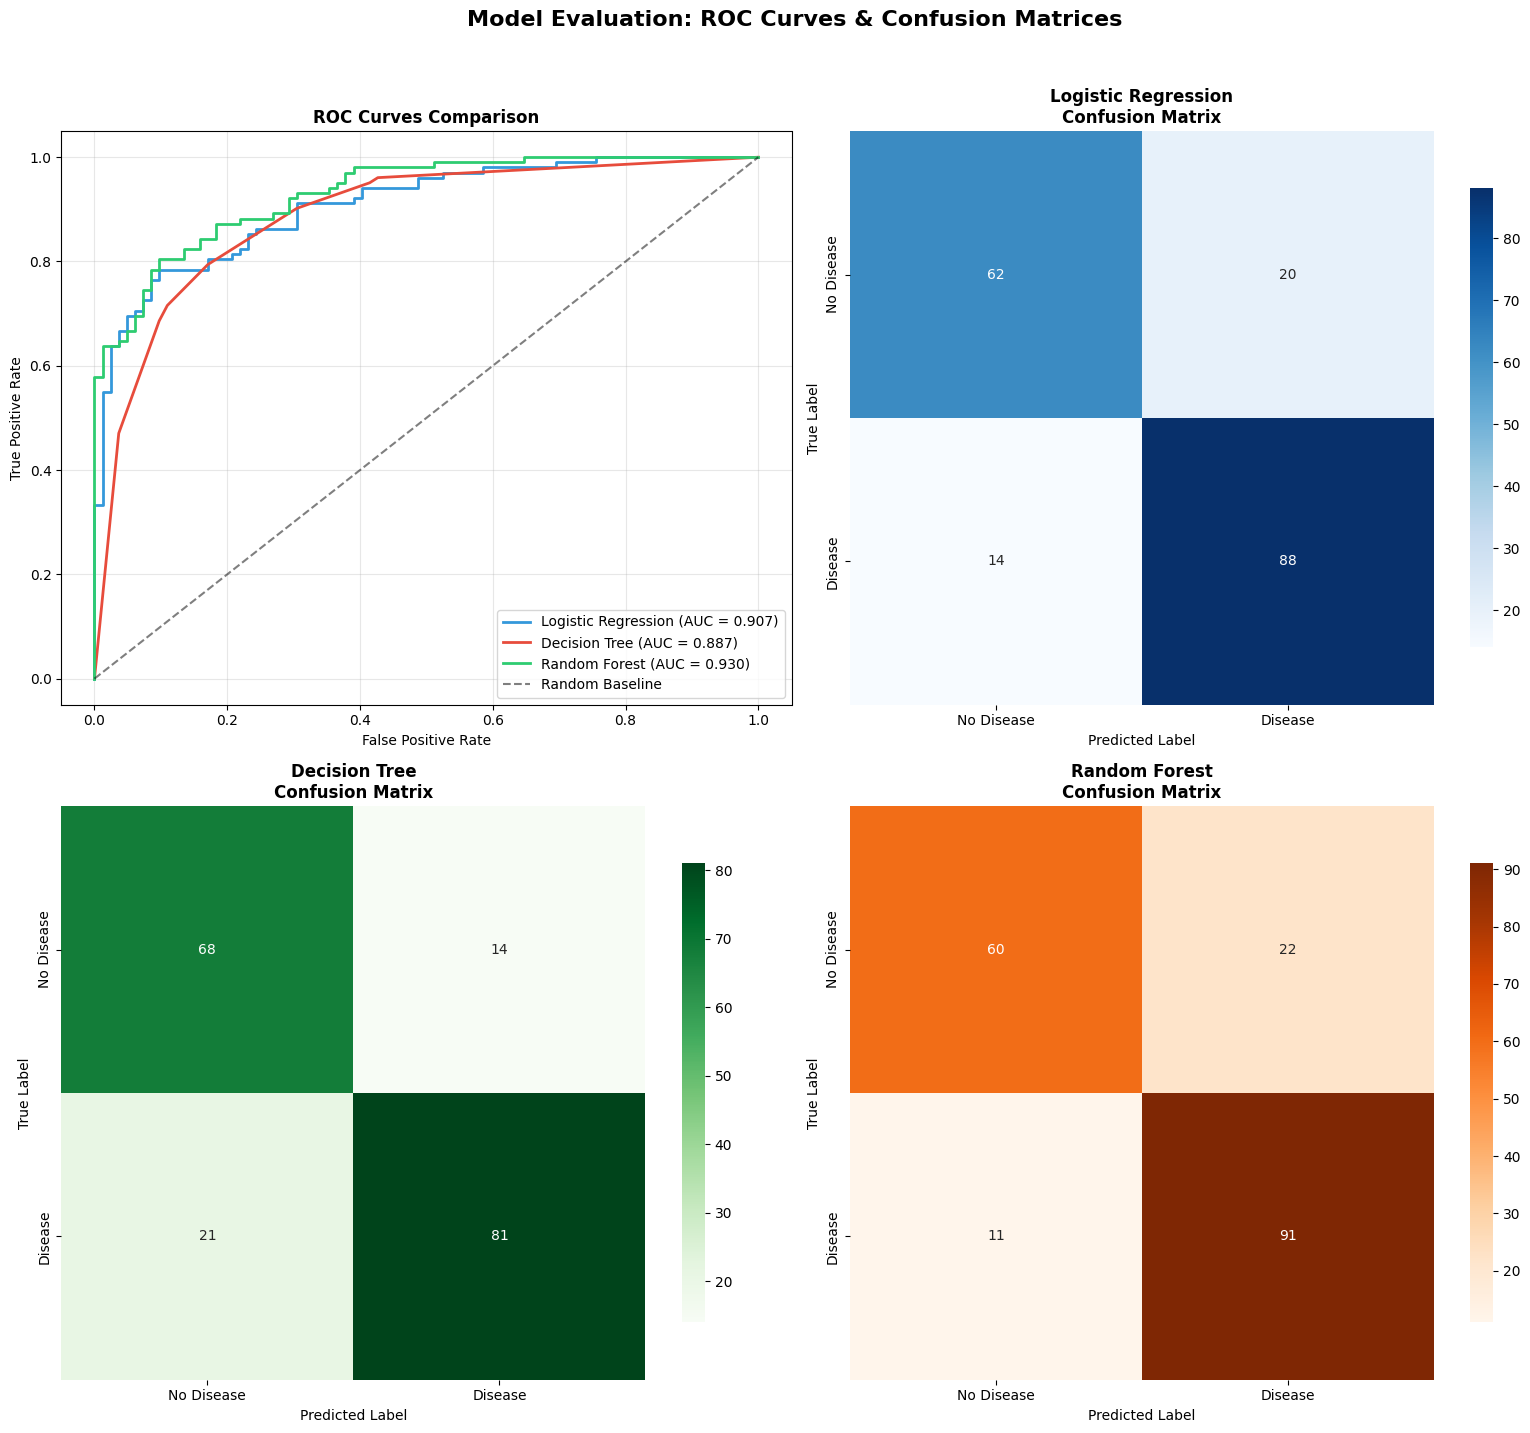


 ROC Curves and Confusion Matrices saved!


In [63]:
print("\n" + "=" * 80)
print("STEP 9: ROC CURVES & CONFUSION MATRICES")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Model Evaluation: ROC Curves & Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)

# ROC Curves
ax1 = axes[0, 0]

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
ax1.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', linewidth=2, color='#3498db')

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_pred_proba)
ax1.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {dt_auc:.3f})', linewidth=2, color='#e74c3c')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
ax1.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.3f})', linewidth=2, color='#2ecc71')

# Random baseline
ax1.plot([0, 1], [0, 1], 'k--', label='Random Baseline', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves Comparison', fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Confusion Matrix - Logistic Regression
ax2 = axes[0, 1]
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'],
            cbar_kws={'shrink': 0.8})
ax2.set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# Confusion Matrix - Decision Tree
ax3 = axes[1, 0]
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', ax=ax3,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'],
            cbar_kws={'shrink': 0.8})
ax3.set_title('Decision Tree\nConfusion Matrix', fontweight='bold')
ax3.set_ylabel('True Label')
ax3.set_xlabel('Predicted Label')

# Confusion Matrix - Random Forest
ax4 = axes[1, 1]
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Oranges', ax=ax4,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'],
            cbar_kws={'shrink': 0.8})
ax4.set_title('Random Forest\nConfusion Matrix', fontweight='bold')
ax4.set_ylabel('True Label')
ax4.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('roc_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n ROC Curves and Confusion Matrices saved!")


# ============================================================
# STEP 10: FEATURE IMPORTANCE ANALYSIS
# ============================================================


STEP 10: FEATURE IMPORTANCE ANALYSIS


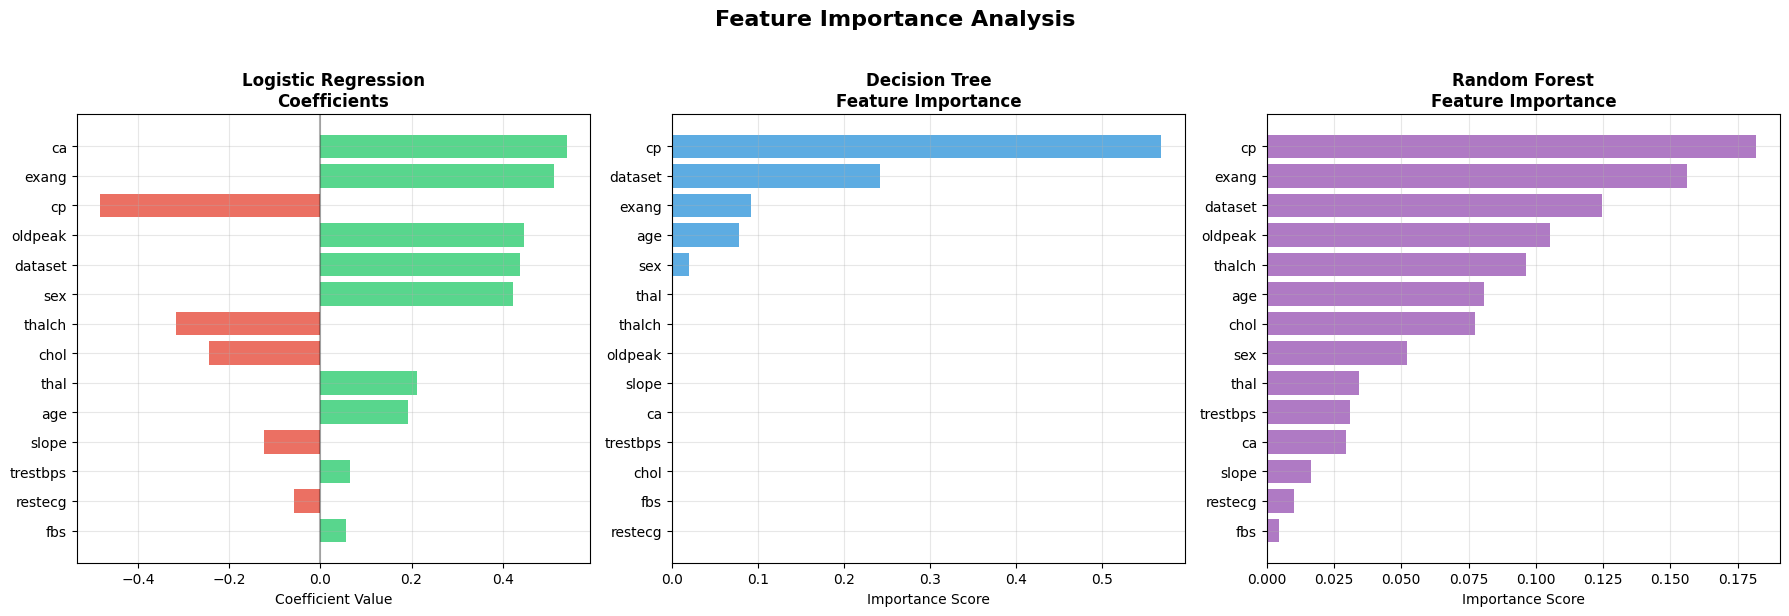


 TOP 5 MOST IMPORTANT FEATURES (by model):

 Logistic Regression (by |coefficient|):
   • ca: 0.540 (↑ increases risk)
   • exang: 0.513 (↑ increases risk)
   • cp: -0.483 (↓ decreases risk)
   • oldpeak: 0.447 (↑ increases risk)
   • dataset: 0.438 (↑ increases risk)

 Decision Tree:
   • cp: 0.568
   • dataset: 0.242
   • exang: 0.091
   • age: 0.078
   • sex: 0.021

 Random Forest:
   • cp: 0.182
   • exang: 0.156
   • dataset: 0.124
   • oldpeak: 0.105
   • thalch: 0.096


In [64]:
print("\n" + "=" * 80)
print("STEP 10: FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importance Analysis', fontsize=16, fontweight='bold', y=1.02)

# 1. Logistic Regression Coefficients
ax1 = axes[0]
lr_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lr.coef_[0]
})
lr_coef['Abs_Coefficient'] = np.abs(lr_coef['Coefficient'])
lr_coef = lr_coef.sort_values('Abs_Coefficient', ascending=True)

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in lr_coef['Coefficient']]
ax1.barh(lr_coef['Feature'], lr_coef['Coefficient'], color=colors, alpha=0.8)
ax1.set_xlabel('Coefficient Value')
ax1.set_title('Logistic Regression\nCoefficients', fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax1.grid(True, alpha=0.3)

# 2. Decision Tree Feature Importance
ax2 = axes[1]
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values('Importance', ascending=True)

ax2.barh(dt_importance['Feature'], dt_importance['Importance'], color='#3498db', alpha=0.8)
ax2.set_xlabel('Importance Score')
ax2.set_title('Decision Tree\nFeature Importance', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Random Forest Feature Importance
ax3 = axes[2]
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

ax3.barh(rf_importance['Feature'], rf_importance['Importance'], color='#9b59b6', alpha=0.8)
ax3.set_xlabel('Importance Score')
ax3.set_title('Random Forest\nFeature Importance', fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n TOP 5 MOST IMPORTANT FEATURES (by model):")
print("\n Logistic Regression (by |coefficient|):")
for _, row in lr_coef.tail(5).iloc[::-1].iterrows():
    direction = "↑ increases" if row['Coefficient'] > 0 else "↓ decreases"
    print(f"   • {row['Feature']}: {row['Coefficient']:.3f} ({direction} risk)")

print("\n  Decision Tree:")
for _, row in dt_importance.tail(5).iloc[::-1].iterrows():
    print(f"   • {row['Feature']}: {row['Importance']:.3f}")

print("\n Random Forest:")
for _, row in rf_importance.tail(5).iloc[::-1].iterrows():
    print(f"   • {row['Feature']}: {row['Importance']:.3f}")


# ============================================================
# STEP 11: CROSS-VALIDATION & MODEL STABILITY
# ============================================================

In [66]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("\n" + "=" * 80)
print("STEP 11: CROSS-VALIDATION & MODEL STABILITY")
print("=" * 80)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(best_lr, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
dt_cv_scores = cross_val_score(best_dt, X_train, y_train, cv=cv, scoring='roc_auc')
rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring='roc_auc')

print("\n 5-Fold Cross-Validation ROC-AUC Scores:")
print(f"\n Logistic Regression:")
print(f"   • Scores: {lr_cv_scores}")
print(f"   • Mean: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std()*2:.4f})")

print(f"\n Decision Tree:")
print(f"   • Scores: {dt_cv_scores}")
print(f"   • Mean: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std()*2:.4f})")

print(f"\n Random Forest:")
print(f"   • Scores: {rf_cv_scores}")
print(f"   • Mean: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std()*2:.4f})")


STEP 11: CROSS-VALIDATION & MODEL STABILITY

 5-Fold Cross-Validation ROC-AUC Scores:

 Logistic Regression:
   • Scores: [0.869606   0.79928919 0.88365133 0.92480359 0.88281102]
   • Mean: 0.8720 (+/- 0.0817)

 Decision Tree:
   • Scores: [0.80600375 0.77768425 0.82033296 0.88131313 0.84254511]
   • Mean: 0.8256 (+/- 0.0698)

 Random Forest:
   • Scores: [0.85572233 0.81126076 0.90385335 0.94032922 0.88831909]
   • Mean: 0.8799 (+/- 0.0876)
